# 02 — Exploratory Data Analysis (EDA)

**Ziel**: Datenverteilungen verstehen, Plausibilität prüfen, Findings für die Dokumentation festhalten.

In [4]:
import os
if not os.path.exists('/content/cyclesync'):
    !git clone https://github.com/carvacla/cyclesync_KI_project.git /content/cyclesync

%cd /content/cyclesync/notebooks

!pip install -q biopython
%run 01_data_acquisition.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

import os
if not os.path.exists('/content/cyclesync'):
    !git clone https://github.com/carvacla/cyclesync_KI_project.git /content/cyclesync
%cd /content/cyclesync/notebooks

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
ABSTRACTS_PATH = Path('../data/pubmed_abstracts')
DATA_PROCESSED.mkdir(exist_ok=True)

cycle_df = pd.read_csv(DATA_RAW / 'cycle_tracking.csv')
workout_df = pd.read_csv(DATA_RAW / 'workouts.csv')

with open(ABSTRACTS_PATH / 'pubmed_abstracts.jsonl', 'r') as f:
    abstracts = [json.loads(line) for line in f]

print(f'Cycle: {cycle_df.shape} | Workouts: {workout_df.shape} | Abstracts: {len(abstracts)}')

/content/cyclesync/notebooks
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.3 MB/s eta 0:00:00
/content/cyclesync/notebooks
Raw data: /content/cyclesync/notebooks/../data/raw
Abstracts: /content/cyclesync/notebooks/../data/pubmed_abstracts
Cycle tracking dataset: (42000, 11)
Workout dataset: (10000, 13)
Label-Verteilung:
recommended_intensity
low         20206
high        14736
moderate     7058
Name: count, dtype: int64
Query "menstrual cycle exercise performance": 50 Treffer
Query "luteal phase training strength": 50 Treffer
Query "follicular phase athletic performance": 50 Treffer
Query "menstrual cycle recovery sleep": 32 Treffer
Query "hormonal fluctuations sports women": 50 Treffer
Query "premenstrual syndrome exercise": 50 Treffer
Query "estrogen progesterone exercise physiology": 34 Treffer
Query "menstrual cycle injury risk female athletes": 50 Treffer

Gesamt unique PMIDs: 317
Batch 1: 48 Abstracts so far
Batch 2: 97 Abstracts so far
Batch 3: 145 Abstracts so far
B

## 1. Cycle-Tracking-Daten

In [5]:
cycle_df.describe()

,user_id,cycle_num,day_in_cycle,bbt_celsius,sleep_hours,sleep_quality,resting_hr,age
count,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.00000,42000.000000,42000.000000
mean,249.500000,1.000000,14.500000,36.56791,7.172974,5.80481,64.877857,29.644000
std,144.338997,0.816506,8.077843,0.23185,0.856336,1.74448,8.446793,7.631949
min,0.000000,0.000000,1.000000,35.83000,4.000000,1.00000,45.000000,18.000000
25%,124.750000,0.000000,7.750000,36.40000,6.600000,5.00000,59.000000,24.000000
50%,249.500000,1.000000,14.500000,36.55000,7.200000,6.00000,65.000000,29.000000
75%,374.250000,2.000000,21.250000,36.73000,7.700000,7.00000,71.000000,35.000000
max,499.000000,2.000000,28.000000,37.51000,10.000000,10.00000,90.000000,50.000000


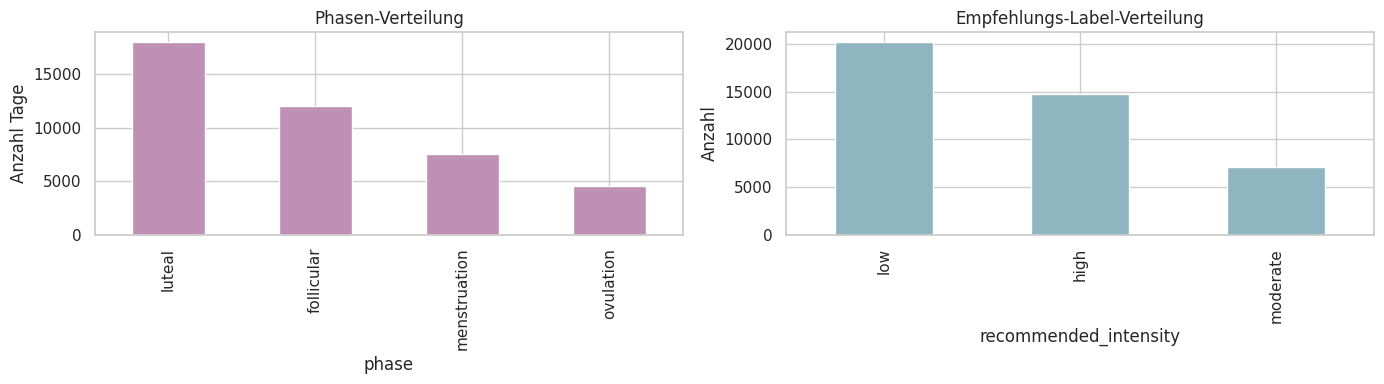

In [6]:
# Phasen-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cycle_df['phase'].value_counts().plot(kind='bar', ax=axes[0], color='#c08fb5')
axes[0].set_title('Phasen-Verteilung')
axes[0].set_ylabel('Anzahl Tage')

cycle_df['recommended_intensity'].value_counts().plot(kind='bar', ax=axes[1], color='#8fb5c0')
axes[1].set_title('Empfehlungs-Label-Verteilung')
axes[1].set_ylabel('Anzahl')
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

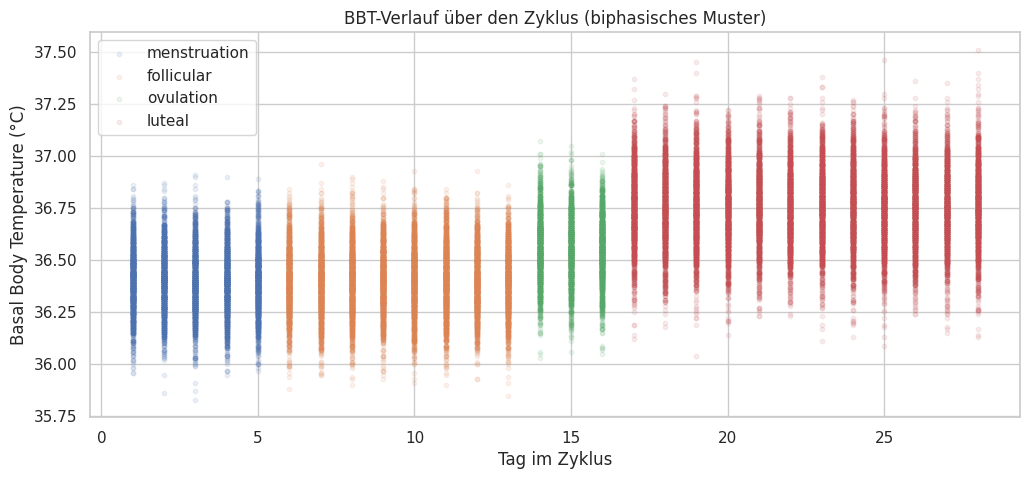

In [7]:
# BBT über Zyklustage
plt.figure(figsize=(12, 5))
for phase in ['menstruation', 'follicular', 'ovulation', 'luteal']:
    subset = cycle_df[cycle_df['phase'] == phase]
    plt.scatter(subset['day_in_cycle'], subset['bbt_celsius'], alpha=0.1, label=phase, s=10)
plt.xlabel('Tag im Zyklus')
plt.ylabel('Basal Body Temperature (°C)')
plt.title('BBT-Verlauf über den Zyklus (biphasisches Muster)')
plt.legend()
plt.savefig('../docs/screenshots/eda_bbt_curve.png', dpi=100, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4202/78692818.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cycle_df, x='phase', y='sleep_quality', order=phase_order, ax=axes[0], palette='pastel')
/tmp/ipykernel_4202/78692818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cycle_df, x='phase', y='sleep_hours', order=phase_order, ax=axes[1], palette='pastel')


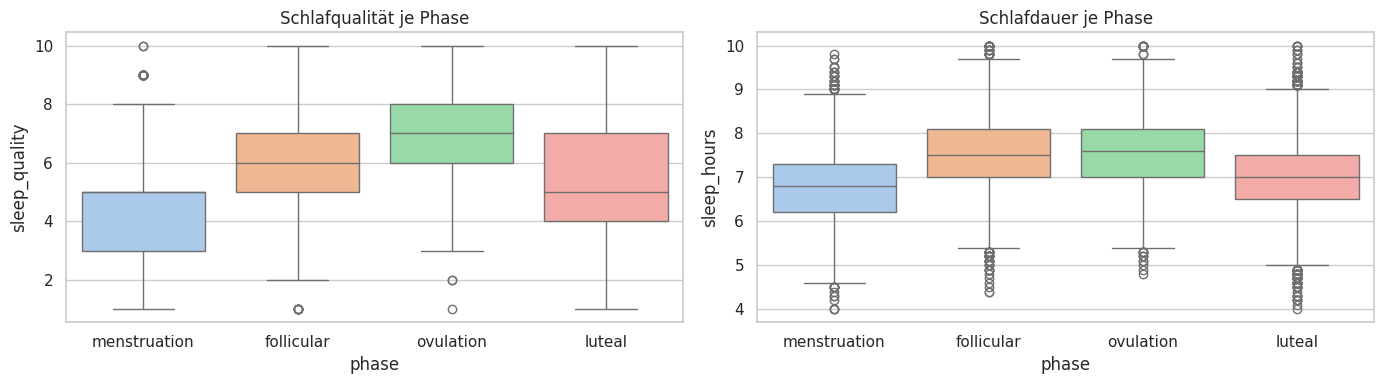

In [8]:
# Schlafqualität je Phase
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
phase_order = ['menstruation', 'follicular', 'ovulation', 'luteal']
sns.boxplot(data=cycle_df, x='phase', y='sleep_quality', order=phase_order, ax=axes[0], palette='pastel')
axes[0].set_title('Schlafqualität je Phase')
sns.boxplot(data=cycle_df, x='phase', y='sleep_hours', order=phase_order, ax=axes[1], palette='pastel')
axes[1].set_title('Schlafdauer je Phase')
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_sleep_per_phase.png', dpi=100, bbox_inches='tight')
plt.show()

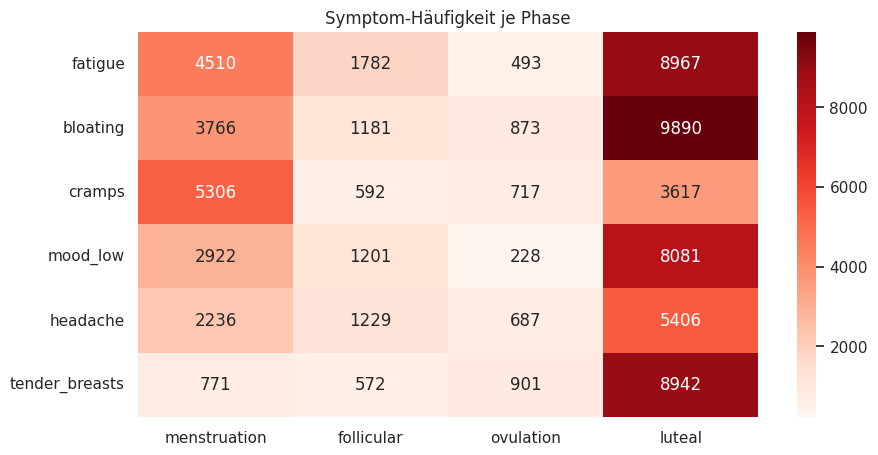

In [9]:
# Symptom-Häufigkeit je Phase
from collections import Counter

symptom_counts = {p: Counter() for p in phase_order}
for _, row in cycle_df.iterrows():
    for s in row['symptoms'].split(';'):
        if s != 'none':
            symptom_counts[row['phase']][s] += 1

symptom_df = pd.DataFrame(symptom_counts).fillna(0).astype(int)
plt.figure(figsize=(10, 5))
sns.heatmap(symptom_df, annot=True, fmt='d', cmap='Reds')
plt.title('Symptom-Häufigkeit je Phase')
plt.savefig('../docs/screenshots/eda_symptoms_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Workout-Daten

In [10]:
workout_df.describe()

,user_id,cycle_num,day_in_cycle,duration_min,intensity_target,avg_hr_bpm,rpe,recovery_hours,temp_c,age
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000
mean,249.500000,0.996000,14.537200,44.551500,5.501100,141.952100,5.952420,31.59870,14.891500,29.64400
std,144.344496,0.809722,8.049602,14.814719,1.698378,14.169378,1.811186,15.29927,8.090918,7.63224
min,0.000000,0.000000,1.000000,15.000000,3.000000,99.000000,1.400000,6.00000,-11.000000,18.00000
25%,124.750000,0.000000,8.000000,34.000000,4.000000,132.000000,4.500000,20.00000,9.500000,24.00000
50%,249.500000,1.000000,15.000000,44.000000,6.000000,142.000000,6.000000,30.00000,14.800000,29.00000
75%,374.250000,2.000000,21.000000,55.000000,7.000000,152.000000,7.400000,41.00000,20.400000,35.00000
max,499.000000,2.000000,28.000000,105.000000,8.000000,193.000000,10.000000,72.00000,41.800000,50.00000


/tmp/ipykernel_4202/2049250730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=workout_df, x='phase', y='recovery_hours', order=phase_order, ax=axes[0], palette='pastel')
/tmp/ipykernel_4202/2049250730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=workout_df, x='phase', y='rpe', order=phase_order, ax=axes[1], palette='pastel')


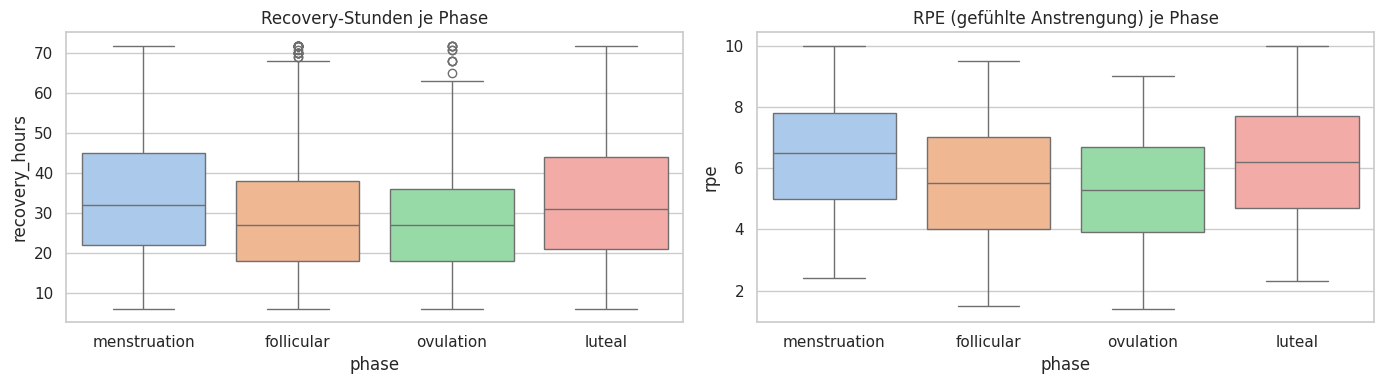

In [11]:
# Recovery-Zeit je Phase und Intensität
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=workout_df, x='phase', y='recovery_hours', order=phase_order, ax=axes[0], palette='pastel')
axes[0].set_title('Recovery-Stunden je Phase')
sns.boxplot(data=workout_df, x='phase', y='rpe', order=phase_order, ax=axes[1], palette='pastel')
axes[1].set_title('RPE (gefühlte Anstrengung) je Phase')
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_workout_phases.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. PubMed-Abstracts

Anzahl Abstracts: 306
Durchschnittliche Länge: 1792 Zeichen
Median Jahr: 2021.0


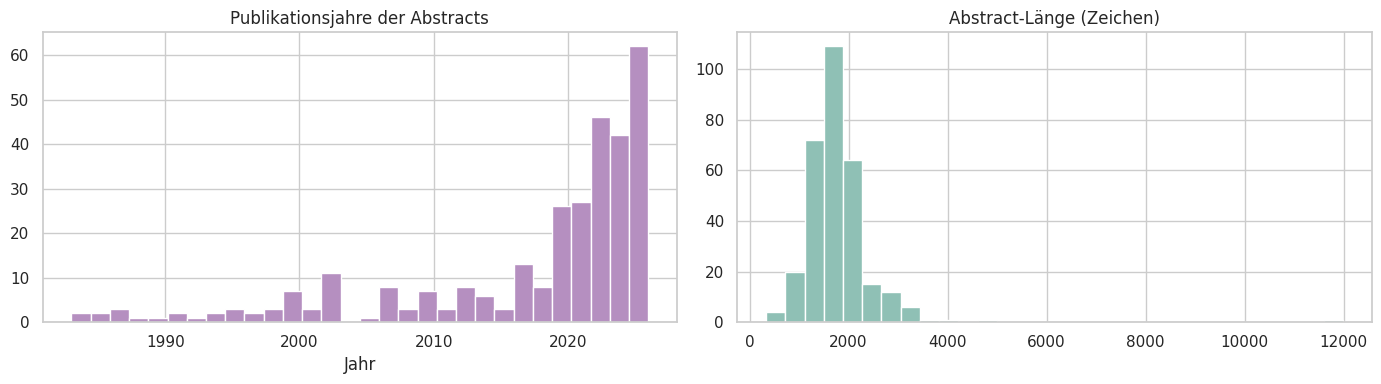

In [12]:
abs_df = pd.DataFrame(abstracts)
abs_df['abstract_length'] = abs_df['abstract'].str.len()
print(f'Anzahl Abstracts: {len(abs_df)}')
print(f'Durchschnittliche Länge: {abs_df["abstract_length"].mean():.0f} Zeichen')
print(f'Median Jahr: {abs_df["year"].median()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
abs_df['year'].dropna().astype(int).hist(bins=30, ax=axes[0], color='#b58fc0')
axes[0].set_title('Publikationsjahre der Abstracts')
axes[0].set_xlabel('Jahr')
abs_df['abstract_length'].hist(bins=30, ax=axes[1], color='#8fc0b5')
axes[1].set_title('Abstract-Länge (Zeichen)')
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_pubmed.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Processed Data Speichern

In [13]:
# Cycle-Daten für Modell vorbereiten
# Symptome als binäre Features
symptom_list = ['cramps', 'fatigue', 'mood_low', 'headache', 'bloating', 'tender_breasts']
for s in symptom_list:
    cycle_df[f'sym_{s}'] = cycle_df['symptoms'].apply(lambda x: int(s in x.split(';')))

cycle_df['symptom_count'] = cycle_df[[f'sym_{s}' for s in symptom_list]].sum(axis=1)

cycle_df.to_csv(DATA_PROCESSED / 'cycle_processed.csv', index=False)
print('Saved processed cycle data')
cycle_df.head()

Saved processed cycle data


,user_id,cycle_num,day_in_cycle,phase,bbt_celsius,sleep_hours,sleep_quality,symptoms,resting_hr,age,fitness_level,recommended_intensity,sym_cramps,sym_fatigue,sym_mood_low,sym_headache,sym_bloating,sym_tender_breasts,symptom_count
0,0,0,1,menstruation,36.23,7.1,5,fatigue;bloating,67,33,intermediate,low,0,1,0,0,1,0,2
1,0,0,2,menstruation,36.31,6.1,1,cramps;mood_low;headache;bloating,66,33,intermediate,low,1,0,1,1,1,0,4
2,0,0,3,menstruation,36.31,7.3,8,cramps;mood_low;headache,65,33,intermediate,low,1,0,1,1,0,0,3
3,0,0,4,menstruation,36.31,7.6,5,cramps;fatigue;headache,62,33,intermediate,low,1,1,0,1,0,0,3
4,0,0,5,menstruation,36.21,7.7,9,cramps,67,33,intermediate,low,1,0,0,0,0,0,1


## Key Findings (für Doku)

- **BBT folgt erwartetem biphasischen Muster** (Anstieg um Ovulation, Plateau in Luteal)
- **Symptomlast** korreliert stark mit Phase (Menstruation + späte Luteal = höchste Last)
- **Schlafqualität** in Lutealphase und Menstruation niedriger
- **Label-Verteilung** für Trainingsempfehlung leicht imbalanced → bei Modelltraining beachten
- **PubMed-Abstracts** decken Spannweite ab 1980er bis 2024, ausreichend für RAG